# Notebook 01 — Préparation des données REFIT (House 21)

Objectif de ce notebook

Ce notebook correspond aux phases Data Understanding et Data Preparation de la méthodologie CRISP-DM.

Nous allons :
- Charger les données brutes du dataset REFIT – House 21 
- Vérifier la qualité des données (dates, valeurs manquantes, colonnes constantes, etc.) 
- Régulariser la série temporelle sur un pas de 1 minute (les mesures d’origine sont à ~8 secondes) 
- Traiter les valeurs manquantes par interpolation temporelle et remplissage robuste 
- Sauvegarder un fichier propre et régulier prêt pour la modélisation dans le Notebook 02.

Ce notebook construit donc la base de données nettoyée sur laquelle tous les modèles de prédiction seront entraînés.


1. Business Understanding

Problématique : comprendre comment la consommation d’énergie évolue dans le temps pour une maison.

Objectif : fournir au modèle des données propres, normalisées et cohérentes pour la prédiction.

Variable cible : Aggregate (consommation totale du foyer).

Variables explicatives : Appliance1 → 9, éventuellement dérivées temporelles (jour, heure, etc. dans le notebook suivant).

2. Data Understanding

Étape 2.1 — Imports et configuration

## 1. Imports et configuration des chemins

Dans cette section, on importe les librairies nécessaires (pandas, numpy, matplotlib, etc.) et on définit
les chemins vers :
- le fichier brut REFIT (House 21) 
- les dossiers où l’on va sauvegarder les fichiers nettoyés et les modèles (data/processed, models/, reports/).
Ce sont uniquement des préparatifs pour structurer le projet.

In [14]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")

import pandas as pd #manipulation de données
import numpy as np #manipulation de données numériques arrays...
import matplotlib.pyplot as plt #visualisation et création de statistiques 
from pathlib import Path #module qui represente les paths des fichiers 

## 2. Chargement des données brutes REFIT – House 21

On charge ici le fichier brut de la House 21 du dataset REFIT.
Objectifs :
- Convertir la colonne Time en index temporel (`DatetimeIndex`) 
- Trier les lignes par ordre chronologique 
- Vérifier rapidement la taille du dataset (nombre de lignes, nombre de colonnes) et l’intervalle de dates couvert.
Ces vérifications permettent de s’assurer que l’on travaille sur des données cohérentes avant de les transformer.

Étape 2.2 — Chargement et structure initiale

Nous avons commencé par lire proprement le fichier brut House_21.
Nous avons nettoyé les noms de colonnes, standardisé la colonne temporelle, trié les données et supprimé les doublons.
Toutes les colonnes numériques ont aussi été converties correctement.
Cela garantit une base saine avant tout nettoyage et transformations plus avancées.

In [15]:
# LECTURE DU FICHIER BRUT HOUSE_21
# Objectif :
# - Charger les données originales REFIT House_21
# - Nettoyer les noms de colonnes et préparer la colonne temporelle
# - Trier chronologiquement et supprimer les doublons
# - Convertir toutes les colonnes en format numérique
#Lecture du fichier brut House_21
RAW = Path("data/raw/House_21.csv")
assert RAW.exists(), "Place House_21.csv dans data/raw/"
# Lecture du fichier brut
df = pd.read_csv(RAW)
# Nettoyage des noms de colonnes (supprime espaces, renomme DateTime → Time)
df.columns = [c.strip().replace("DateTime","Time") for c in df.columns]
assert "Time" in df.columns

'''- On **nettoie les noms de colonnes** :
  - `strip()` enlève les espaces
  - `replace("DateTime","Time")` renomme la colonne DateTime → Time  
- Vérification qu’une colonne `Time` existe bien (pour index temporel).
'''
# Conversion de la colonne Time en datetime
df["Time"] = pd.to_datetime(df["Time"])
df = df.sort_values("Time").drop_duplicates(subset=["Time"]).set_index("Time")

# Conversion des colonnes numériques
num_cols = list(df.columns)
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

print(df.shape, df.index.min(), "→", df.index.max())
df.head()

(5383993, 11) 2014-03-07 16:20:20 → 2015-07-10 11:56:35


,Unix,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9
Time,,,,,,,,,,,
2014-03-07 16:20:20,1394209220,2339,0,0,2090,0,0,0,11,29,0
2014-03-07 16:20:34,1394209234,2339,0,0,2104,0,21,0,11,29,0
2014-03-07 16:20:49,1394209249,2291,0,0,2090,0,21,0,11,29,0
2014-03-07 16:21:03,1394209263,2338,0,0,2090,0,21,0,11,30,0
2014-03-07 16:21:17,1394209277,2298,0,0,2090,0,26,0,11,29,0


Étape 2.3 — Diagnostic qualité et compréhension du pas temporel

## 3. Analyse rapide de la qualité des données

Avant de transformer la série, on réalise quelques contrôles :
- Nombre de valeurs manquantes par colonne : pour voir quelles colonnes sont les plus problématiques 
- Colonnes constantes : colonnes qui ne varient jamais ==> peu informatives pour la modélisation 
- Pas de temps entre deux mesures successives : on vérifie si les mesures sont proches de 6–8 secondes
  mais avec des irrégularités.
Ces informations motivent ensuite :
- le re-échantillonnage à 1 minute ;
- et le traitement des valeurs manquantes.

In [16]:
# Compte le nombre de valeurs NaN dans chaque colonne et affiche les 10 colonnes avec le plus de NaN
print("NA par colonne (top 10):")
display(df.isna().sum().sort_values(ascending=False).head(10))

# Analyse l'intervalle de temps entre les mesures consécutives
# Convertit l'index en série, calcule les différences de temps en secondes et supprime les valeurs NaN
pas = df.index.to_series().diff().dropna().dt.total_seconds()
# Affiche la médiane, le 90ème percentile et le 99ème percentile des intervalles de temps
print("Pas (sec) — médiane/90e/99e:", pas.quantile([.5,.9,.99]).to_dict())

NA par colonne (top 10):


Unix          0
Aggregate     0
Appliance1    0
Appliance2    0
Appliance3    0
Appliance4    0
Appliance5    0
Appliance6    0
Appliance7    0
Appliance8    0
dtype: int64

Pas (sec) — médiane/90e/99e: {0.5: 7.0, 0.9: 14.0, 0.99: 15.0}


3. Data Preparation

(objectif : nettoyer, organiser, transformer)

Étape 3.1 — Nettoyage de base

In [17]:
# Limite toutes les valeurs du dataframe à être au moins 0 (remplace les valeurs négatives par 0)
df = df.clip(lower=0)

# Identifie les colonnes qui n'ont qu'une seule valeur unique (en excluant les valeurs NaN)
# Ces colonnes constantes ne sont généralement pas utiles pour la modélisation
const_cols = [c for c in df.columns if df[c].nunique(dropna=True)<=1]
print("Colonnes constantes :", const_cols)

Colonnes constantes : []


## 4. Régularisation temporelle : passage à un pas de 1 minute

Les mesures REFIT sont enregistrées environ toutes les 6–8 secondes, mais de manière irrégulière.
Pour la modélisation en Data Science, il est beaucoup plus pratique d’avoir :
- une série régulière (même pas de temps entre chaque ligne),
- un pas de temps plus macro (ici 1 minute) pour réduire le bruit et le volume de données.
Nous utilisons donc :

In [18]:
# Re-échantillonnage du dataframe
# Conversion des intervalles d'environ 8 secondes à des intervalles d'une minute
# Utilisation de mean() pour agréger les valeurs dans chaque fenêtre d'une minute
df_1min = df.resample("1min").mean()

# Affichage de la forme du dataframe re-échantillonné et de sa plage temporelle
print(df_1min.shape, df_1min.index.min(), "→", df_1min.index.max())

# Affichage des 5 premières lignes du dataframe re-échantillonné
df_1min.head()

(705337, 11) 2014-03-07 16:20:00 → 2015-07-10 11:56:00


,Unix,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9
Time,,,,,,,,,,,
2014-03-07 16:20:00,1.394209e+09,2323.000000,0.0,0.0,2094.666667,0.0,14.000000,0.0,11.000000,29.000000,0.0
2014-03-07 16:21:00,1.394209e+09,2337.428571,0.0,0.0,2094.571429,0.0,22.428571,0.0,11.285714,29.428571,0.0
2014-03-07 16:22:00,1.394209e+09,507.875000,0.0,0.0,69.500000,0.0,20.125000,0.0,11.875000,30.125000,0.0
2014-03-07 16:23:00,1.394209e+09,236.400000,0.0,0.0,73.700000,0.0,20.100000,0.0,11.600000,30.100000,0.0
2014-03-07 16:24:00,1.394209e+09,211.900000,0.0,0.0,71.200000,0.0,20.000000,0.0,11.300000,29.700000,0.0


In [19]:
def zero_runs_to_nan(s, min_run=10):
    """
    Remplace par NaN les longues séquences de zéros consécutifs
    dans une série s (par exemple une série de consommation).

    Paramètres
    ----------
    s : pandas.Series
        Série à traiter (ex : df_1min["Aggregate"])
    min_run : int
        Longueur minimale d'un run de zéros pour être considéré comme suspect
        (par défaut 10 minutes consécutives).

    Idée :
    - de petits passages à 0 peuvent être réels,
    - mais des suites très longues de 0 ressemblent plutôt à une panne de capteur.
    """
    s = s.copy()  # on travaille sur une copie pour ne pas modifier la série d'origine
    # Série booléenne : True là où s vaut 0, False sinon
    is_zero = (s == 0)
    # On détecte les "runs" (séquences consécutives) en numérotant les groupes
    # Chaque fois que is_zero change (False -> True ou True -> False), on incrémente un groupe
    grp = (is_zero != is_zero.shift()).cumsum()
    # Pour chaque groupe, on calcule la longueur du run (somme des True)
    # et on "réplique" cette longueur sur toutes les lignes du groupe
    run_len = is_zero.groupby(grp).transform("sum")
    # On remplace par NaN les valeurs qui sont 0 ET qui appartiennent
    # à un run de longueur >= min_run
    s[(is_zero) & (run_len >= min_run)] = np.nan
    return s

# Application spécifique à la colonne Aggregate
if "Aggregate" in df_1min.columns:
    # Nombre de zéros avant nettoyage
    before = int((df_1min["Aggregate"] == 0).sum())
    # Nettoyage des longs runs de zéros (>= 10) dans Aggregate
    df_1min["Aggregate"] = zero_runs_to_nan(df_1min["Aggregate"], min_run=10)
    # Nombre de zéros qui restent (zéros isolés ou runs courts)
    after = int((df_1min["Aggregate"] == 0).sum())
    print(f"Zeros Aggregate avant: {before} | après: {after}")

Zeros Aggregate avant: 0 | après: 0


In [20]:
# Étape : Interpolation temporelle + lissage léger

# Remplacer les NaN en utilisant une interpolation basée sur le temps.
# - method="time" : suit la logique chronologique d'une série temporelle
# - limit=60      : n'interpole pas des trous > 60 minutes
# - limit_direction="both" : interpolation possible vers avant et vers arrière
df_interp = df_1min.interpolate(method="time", limit=60, limit_direction="both")

# Lissage léger de la série 'Aggregate' :
# On applique une moyenne mobile sur une fenêtre de 3 minutes.
# Cela permet de réduire le bruit (petits pics très rapides) sans modifier
# la tendance globale de la consommation.
if "Aggregate" in df_interp.columns:
    # Applique une moyenne mobile à la colonne Aggregate
    # - fenêtre de taille 3 périodes temporelles 
    # - min_periods=1 permet le calcul même aux bords des données où une fenêtre complète n'est pas disponible
    # Ce lissage réduit le bruit à court terme tout en préservant la tendance générale de consommation
    df_interp["Aggregate"] = (
        df_interp["Aggregate"]
        .rolling(3, min_periods=1)
        .mean()
    )

In [21]:
#  Étape : gestion des valeurs extrêmes (outliers)

# On crée une copie de df_interp pour appliquer les transformations
clean = df_interp.copy()

# On cible uniquement les colonnes de puissance :
# - Aggregate (consommation totale)
# - Appliance1..9 (consommation par appareil)
cols_power = [c for c in clean.columns if c.lower().startswith(("aggregate", "appliance"))]

for c in cols_power:
    # On calcule le 99.9e percentile de la colonne c
    # → au-delà de cette valeur, on considère les points comme des valeurs extrêmes
    q_hi = clean[c].quantile(0.999)
    
    # Capping (winsorisation) :
    # si la valeur dépasse q_hi, on la remplace par q_hi,
    # sinon on garde la valeur telle quelle.
    clean[c] = np.where(clean[c] > q_hi, q_hi, clean[c])

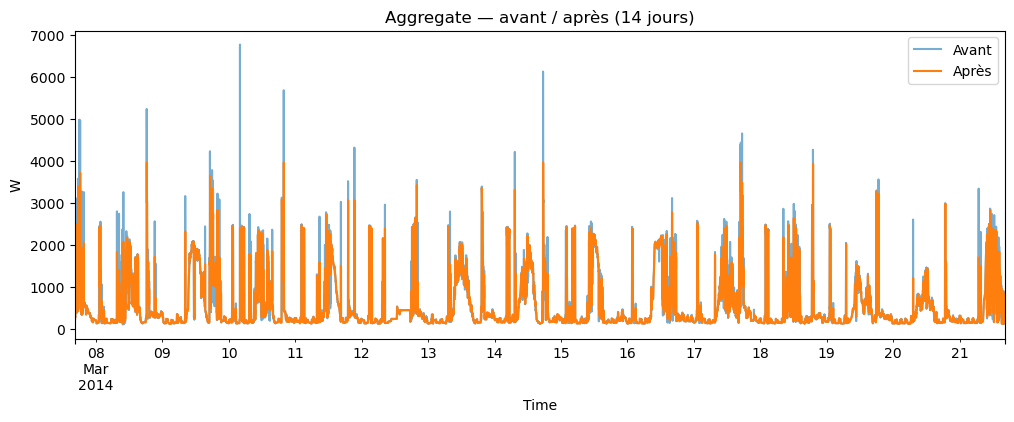

In [22]:
#  Visualisation de l'effet du nettoyage (Aggregate)

# On prend une fenêtre de 14 jours au début de la série pour faire une comparaison visuelle
t0 = clean.index.min()
t1 = t0 + pd.Timedelta(days=14)

plt.figure(figsize=(12, 4))

# Courbe avant nettoyage des outliers (à partir df_1min)
df_1min["Aggregate"].loc[t0:t1].plot(label="Avant", alpha=0.6)

# Courbe après capping (sur clean)
clean["Aggregate"].loc[t0:t1].plot(label="Après")

plt.title("Aggregate — avant / après (14 jours)")
plt.ylabel("W")
plt.legend()
plt.show()
#on vérifie visuellement l’impact sur les 14 premiers jours : 
#on voit que la série est un peu ‘calmée’ au niveau des gros pics, tout en gardant la forme globale.

In [23]:
# Import RobustScaler from sklearn.preprocessing for robust feature scaling
# RobustScaler is less sensitive to outliers compared to StandardScaler
from sklearn.preprocessing import RobustScaler 

# Import joblib for saving and loading scikit-learn models
import joblib

# Diviser les données en ensembles d'entraînement (80%) et de test (20%)
# Calcule l'indice de position pour diviser les données (80% pour l'entraînement)
split_idx = int(len(clean)*0.8)
# Divise le jeu de données nettoyé en ensemble d'entraînement (premiers 80%) et ensemble de test (20% restants)
train, test = clean.iloc[:split_idx], clean.iloc[split_idx:]

# Obtenir toutes les colonnes de caractéristiques sauf la colonne 'Unix'
feat_cols = [c for c in clean.columns if c!="Unix"]

# Initialiser et ajuster le RobustScaler sur les données d'entraînement
# RobustScaler est moins affecté par les valeurs aberrantes que StandardScaler
scaler = RobustScaler().fit(train[feat_cols])

# Créer des copies des ensembles d'entraînement et de test pour préserver les données originales
train_scaled, test_scaled = train.copy(), test.copy()

# Transformer les données d'entraînement et de test en utilisant le scaler ajusté
train_scaled[feat_cols] = scaler.transform(train[feat_cols])
test_scaled[feat_cols]  = scaler.transform(test[feat_cols])

# Créer le répertoire 'models' s'il n'existe pas
Path("models").mkdir(exist_ok=True)

# Sauvegarder le scaler ajusté pour une utilisation future
# Sauvegarde le scaler RobustScaler ajusté dans un fichier pour une utilisation ultérieure
# Cela permettra d'appliquer la même mise à l'échelle aux nouvelles données
joblib.dump(scaler, "models/scaler_house21_robust.joblib")

['models/scaler_house21_robust.joblib']

In [24]:
Path("data/processed").mkdir(exist_ok=True)
clean.to_csv("data/processed/House_21_1min_clean.csv")

import json, datetime
meta = dict(
    house=21,
    created=datetime.datetime.now().isoformat(),
    resample="1min",
    zero_run_to_nan=10,
    interp_limit=60,
    scaler="RobustScaler (fit on train)",
    columns=list(clean.columns),
    period=[str(clean.index.min()), str(clean.index.max())]
)
Path("reports").mkdir(exist_ok=True)
json.dump(meta, open("reports/house21_meta.json","w"), indent=2)
print(" Sauvegardes terminées.")

 Sauvegardes terminées.


In [25]:
# Dernier nettoyage : combler les NaN restants
print("Valeurs manquantes avant correction :", clean.isna().sum().sum())

# interpolation complète
clean = clean.interpolate(method="time", limit_direction="both")

# si quelques NaN persistent → remplir avec la médiane de chaque colonne
clean = clean.fillna(clean.median(numeric_only=True))

print("Valeurs manquantes après correction :", clean.isna().sum().sum())

Valeurs manquantes avant correction : 686121
Valeurs manquantes après correction : 0


In [26]:
assert clean.isna().sum().sum() == 0, " Des NaN subsistent"
assert clean.index.is_monotonic_increasing, "Index temps non trié"
print(" Données prêtes pour la modélisation.")

 Données prêtes pour la modélisation.


In [27]:
# contrôles finaux
assert clean.isna().sum().sum() == 0, "NaN restants"
assert clean.index.is_monotonic_increasing, "Index temps non trié"
assert (clean.select_dtypes(include=['number']) >= 0).all().all(), "Valeurs négatives restantes"

# petit aperçu
clean.info()
clean.describe().T.head(10)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 705337 entries, 2014-03-07 16:20:00 to 2015-07-10 11:56:00
Freq: T
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unix        705337 non-null  float64
 1   Aggregate   705337 non-null  float64
 2   Appliance1  705337 non-null  float64
 3   Appliance2  705337 non-null  float64
 4   Appliance3  705337 non-null  float64
 5   Appliance4  705337 non-null  float64
 6   Appliance5  705337 non-null  float64
 7   Appliance6  705337 non-null  float64
 8   Appliance7  705337 non-null  float64
 9   Appliance8  705337 non-null  float64
 10  Appliance9  705337 non-null  float64
dtypes: float64(11)
memory usage: 80.7 MB


,count,mean,std,min,25%,50%,75%,max
Unix,705337.0,1.415369e+09,1.221680e+07,1.394209e+09,1.404789e+09,1.415369e+09,1.425949e+09,1.436529e+09
Aggregate,705337.0,6.436094e+02,6.629478e+02,6.444444e+01,1.847333e+02,2.851250e+02,9.835000e+02,3.960110e+03
Appliance1,705337.0,4.540273e+01,4.723539e+01,0.000000e+00,1.000000e+00,8.450622e+00,9.177778e+01,2.052222e+02
Appliance2,705337.0,2.044924e+01,1.647080e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.476333e+03
Appliance3,705337.0,1.305139e+01,1.479041e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.137904e+03
Appliance4,705337.0,4.335603e+01,2.624253e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.130000e+03
Appliance5,705337.0,2.678383e-02,7.868724e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01
Appliance6,705337.0,6.382841e+00,1.356374e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.920000e+01
Appliance7,705337.0,5.592165e+00,9.122759e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.072986e+03
Appliance8,705337.0,1.931157e+01,2.583840e+00,0.000000e+00,2.000000e+01,2.000000e+01,2.000000e+01,2.830000e+01


In [28]:
from sklearn.preprocessing import RobustScaler
import joblib
from pathlib import Path

split_idx = int(len(clean)*0.8)
train = clean.iloc[:split_idx].copy()
test  = clean.iloc[split_idx:].copy()

feat_cols = list(clean.columns)
if "Unix" in feat_cols:
    feat_cols.remove("Unix")  # pas utile au modèle

scaler = RobustScaler().fit(train[feat_cols])   # fit sur TRAIN uniquement
train_scaled = train.copy()
test_scaled  = test.copy()
train_scaled[feat_cols] = scaler.transform(train[feat_cols])
test_scaled[feat_cols]  = scaler.transform(test[feat_cols])

Path("models").mkdir(parents=True, exist_ok=True)
joblib.dump(scaler, "models/scaler_house21_robust.joblib")
print(" Scaler réentraîné et sauvegardé → models/scaler_house21_robust.joblib")

 Scaler réentraîné et sauvegardé → models/scaler_house21_robust.joblib


In [29]:
import json
Path("data/processed").mkdir(parents=True, exist_ok=True)
clean.to_csv("data/processed/House_21_1min_clean.csv")

meta = {
    "house": 21,
    "resample": "1min_mean",
    "zero_runs_to_nan_minutes": 10,
    "interpolation_limit_minutes": 60,
    "fillna": "time interpolation + per-column median",
    "smoothing_aggregate_window": 3,
    "winsor_high_q": 0.999,
    "scaler": "RobustScaler (fit on train)",
    "columns": list(clean.columns),
    "period": [str(clean.index.min()), str(clean.index.max())]
}
Path("reports").mkdir(parents=True, exist_ok=True)
json.dump(meta, open("reports/house21_meta.json","w"), indent=2)

print(" Fichier propre : data/processed/House_21_1min_clean.csv")
print(" Meta : reports/house21_meta.json")

 Fichier propre : data/processed/House_21_1min_clean.csv
 Meta : reports/house21_meta.json


Text(0, 0.5, 'W')

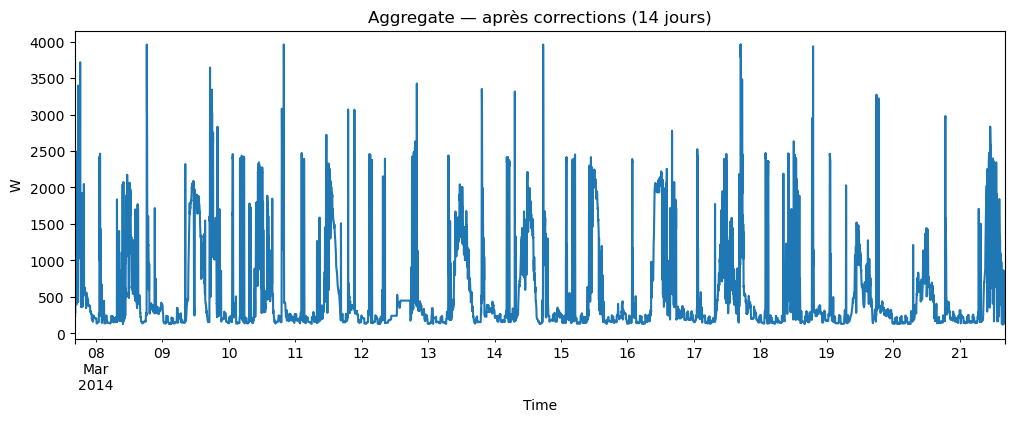

In [30]:
t0 = clean.index.min()
t1 = t0 + pd.Timedelta(days=14)

ax = clean["Aggregate"].loc[t0:t1].plot(figsize=(12,4), title="Aggregate — après corrections (14 jours)")
ax.set_ylabel("W")

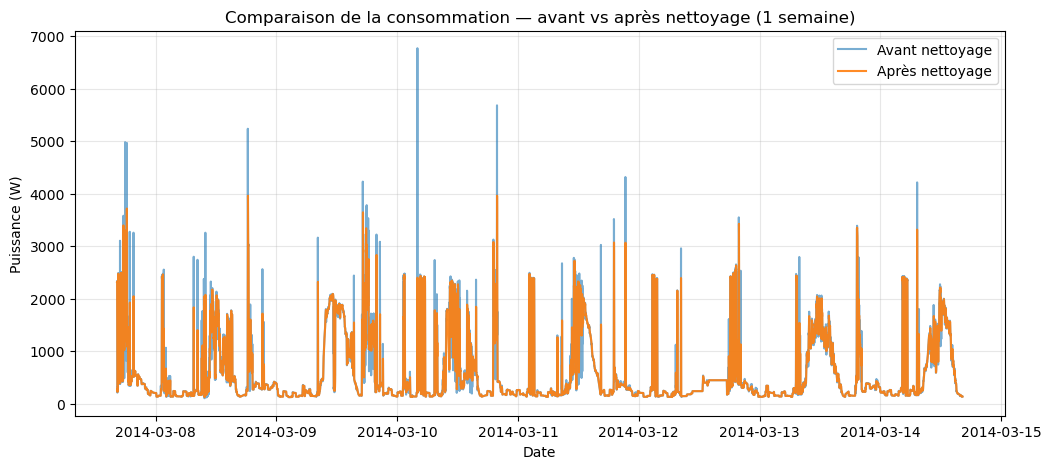

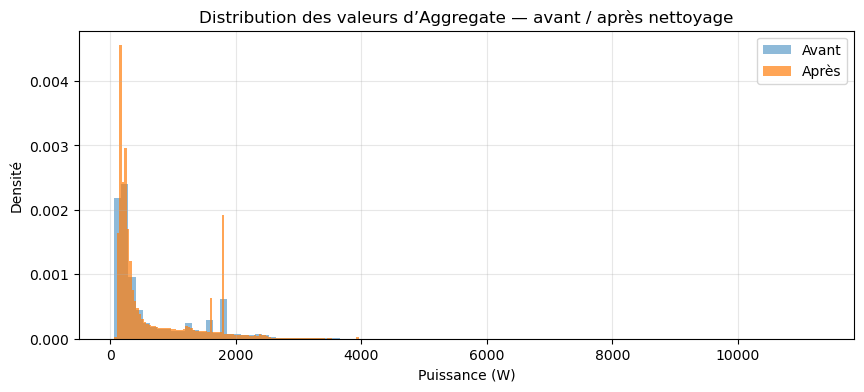

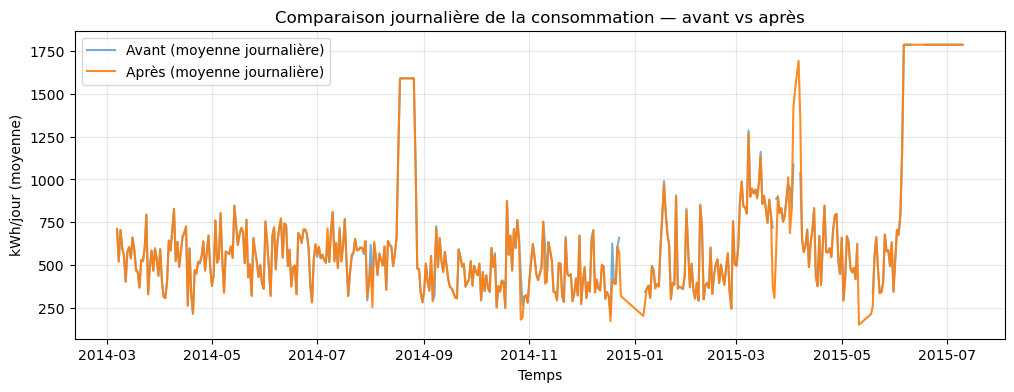

In [31]:
#  Comparaison visuelle avant / après nettoyage complet

import matplotlib.pyplot as plt

# On recharge le brut rééchantillonné (1 min) avant nettoyage
# pour le comparer à la version finale clean
df_raw_1min = df.resample("1min").mean()  # même base temporelle

# Fenêtre de comparaison
t0 = df_raw_1min.index.min()
t1 = t0 + pd.Timedelta(days=7)   # 1 semaine pour comparaison

plt.figure(figsize=(12,5))
plt.plot(df_raw_1min["Aggregate"].loc[t0:t1], label="Avant nettoyage", alpha=0.6, color="tab:blue")
plt.plot(clean["Aggregate"].loc[t0:t1], label="Après nettoyage", alpha=0.9, color="tab:orange")

plt.title("Comparaison de la consommation — avant vs après nettoyage (1 semaine)")
plt.xlabel("Date")
plt.ylabel("Puissance (W)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Histogramme global avant/après
plt.figure(figsize=(10,4))
plt.hist(df_raw_1min["Aggregate"].dropna(), bins=100, alpha=0.5, label="Avant", color="tab:blue", density=True)
plt.hist(clean["Aggregate"].dropna(), bins=100, alpha=0.7, label="Après", color="tab:orange", density=True)
plt.title("Distribution des valeurs d’Aggregate — avant / après nettoyage")
plt.xlabel("Puissance (W)")
plt.ylabel("Densité")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Évolution globale (plus longue période)
plt.figure(figsize=(12,4))
plt.plot(df_raw_1min["Aggregate"].resample("1D").mean(), label="Avant (moyenne journalière)", alpha=0.6)
plt.plot(clean["Aggregate"].resample("1D").mean(), label="Après (moyenne journalière)", alpha=0.9)
plt.title("Comparaison journalière de la consommation — avant vs après")
plt.xlabel("Temps")
plt.ylabel("kWh/jour (moyenne)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()